# 하이퍼파라미터 최적화 기초

같은 모델이라도 설정값을 어떻게 주느냐에 따라 학습 결과가 꽤 달라질 수 있다.

이때 사람이 미리 정해주는 설정값을 하이퍼파라미터라고 한다.

- learning rate
- batch size
- epoch 수
- hidden size
- dropout 비율

이 값들은 데이터에서 자동으로 학습되는 값이 아니라,
실험을 통해 조정해보는 값들이다.

즉,
- 가중치(weight), 편향(bias) 같은 것은 모델이 학습하는 파라미터
- learning rate, batch size 같은 것은 사람이 정하는 하이퍼파라미터

라고 구분하면 된다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

torch.set_num_threads(1)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# 데이터 생성
X, y = make_moons(n_samples=800, noise=0.25, random_state=42)

# train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 입력 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# tensor 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

print('X_train shape:', X_train_t.shape)
print('y_train shape:', y_train_t.shape)
print('X_val shape  :', X_val_t.shape)
print('y_val shape  :', y_val_t.shape)

X_train shape: torch.Size([600, 2])
y_train shape: torch.Size([600, 1])
X_val shape  : torch.Size([200, 2])
y_val shape  : torch.Size([200, 1])


In [3]:
# 이진분류용 MLP 모델
# hidden_size로 은닉층 크기를 조절할 수 있고,
# dropout_rate로 dropout 비율을 조절할 수 있다.
class BinaryMLP(nn.Module):
    def __init__(self, hidden_size=16, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)


# TensorDataset과 DataLoader를 만들어
# mini-batch 단위로 학습할 수 있게 해주는 함수
def make_loader(X, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


# 현재 모델의 loss와 accuracy를 계산하는 평가 함수
# train set / validation set 모두 같은 방식으로 재사용할 수 있다.
def evaluate_model(model, X, y, loss_fn):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss = loss_fn(logits, y).item()
        pred = (torch.sigmoid(logits) >= 0.5).float()
        acc = (pred == y).float().mean().item()
    return loss, acc


# 모델 생성부터 학습, epoch별 성능 기록까지 한 번에 수행하는 함수
# dropout, hidden size, batch size, learning rate 등을 바꿔 실험할 수 있다.
def train_model(
    lr=0.01,
    batch_size=32,
    hidden_size=16,
    dropout_rate=0.0,
    epochs=80,
    seed=42
):
    torch.manual_seed(seed)

    model = BinaryMLP(hidden_size=hidden_size, dropout_rate=dropout_rate)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    train_loader = make_loader(X_train_t, y_train_t, batch_size=batch_size, shuffle=True)

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):
        model.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_model(model, X_train_t, y_train_t, loss_fn)
        val_loss, val_acc = evaluate_model(model, X_val_t, y_val_t, loss_fn)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    return {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'train_acc': train_acc_history,
        'val_acc': val_acc_history,
    }


# 여러 실험 결과 중 하나의 지표를 골라
# epoch에 따른 변화를 그래프로 비교하는 함수
def plot_metric(results_dict, metric='val_loss', title=''):
    plt.figure(figsize=(8, 4))
    for label, history in results_dict.items():
        plt.plot(history[metric], label=label)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# 각 실험의 마지막 train/val accuracy와
# 가장 높았던 validation accuracy를 요약 출력하는 함수
def summarize_final(results_dict):
    for label, history in results_dict.items():
        print(
            f'{label:>15} | '
            f'final train acc: {history["train_acc"][-1]:.4f} | '
            f'final val acc: {history["val_acc"][-1]:.4f} | '
            f'best val acc: {max(history["val_acc"]):.4f}'
        )

## 1. learning rate 조절

learning rate는 한 번의 업데이트에서 가중치를 얼마나 크게 움직일지를 정하는 값이다.

- 너무 작으면 학습이 매우 느릴 수 있다.
- 너무 크면 손실이 흔들리거나 발산할 수 있다.
- 적절하면 빠르고 안정적으로 수렴한다.

       lr=0.001 | final train acc: 0.9467 | final val acc: 0.9550 | best val acc: 0.9600
        lr=0.01 | final train acc: 0.9467 | final val acc: 0.9400 | best val acc: 0.9750
         lr=0.1 | final train acc: 0.9450 | final val acc: 0.9450 | best val acc: 0.9750
         lr=1.0 | final train acc: 0.5000 | final val acc: 0.5000 | best val acc: 0.9100


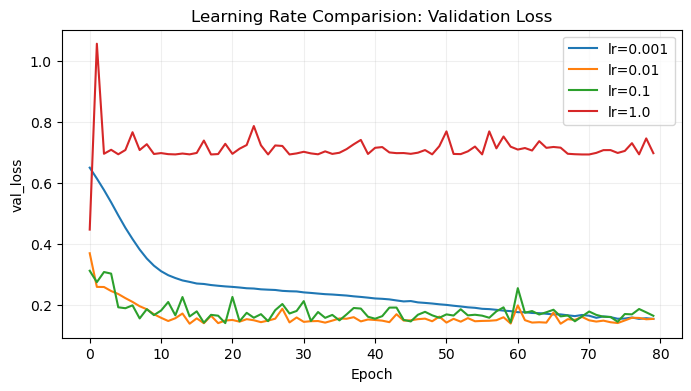

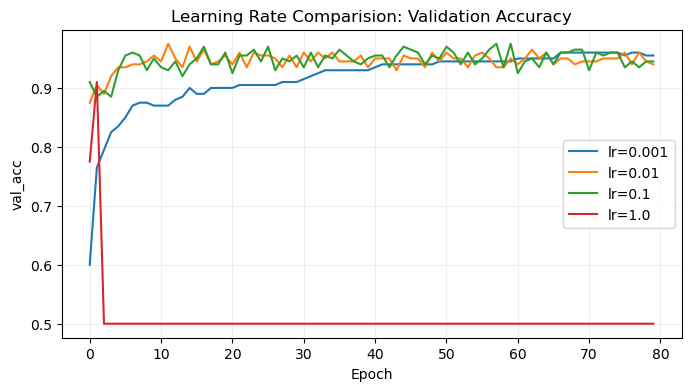

In [27]:
learning_rate_results = {
    'lr=0.001' : train_model(lr=0.001, epochs=80, seed=42),
    'lr=0.01' : train_model(lr=0.01, epochs=80, seed=42),
    'lr=0.1' : train_model(lr=0.1, epochs=80, seed=42),
    'lr=1.0' : train_model(lr=1.0, epochs=80, seed=42),
}

summarize_final(learning_rate_results)
plot_metric(learning_rate_results, metric='val_loss', title='Learning Rate Comparision: Validation Loss')
plot_metric(learning_rate_results, metric='val_acc', title='Learning Rate Comparision: Validation Accuracy')

## 2. batch size 조절

batch size는 한 번의 파라미터 업데이트 전에 몇 개의 샘플을 묶어서 볼지 정하는 값이다.

- batch size가 작으면 업데이트가 자주 일어난다.
- batch size가 크면 한 번의 업데이트가 더 안정적일 수 있다.
- 하지만 너무 크면 메모리를 많이 쓰고, 일반화가 항상 좋아지는 것도 아니다.

즉 batch size는 **학습의 흔들림 정도**, **업데이트 빈도**, **메모리 사용량** 과 함께 생각해야 한다.

In [28]:
batch_size_results = {
    'batch=8' : train_model(batch_size=8, epochs=80, seed=42),
    'batch=32' : train_model(batch_size=32, epochs=80, seed=42),
    'batch=128' : train_model(batch_size=128, epochs=80, seed=42),
}

summarize_final(batch_size_results)
plot_metric(batch_size_results, metric='val_loss', title='Batch Size Comparision: Validation Loss')
plot_metric(batch_size_results, metric='val_acc', title='Batch Size Comparision: Validation Accuracy')

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.0
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda




KeyboardInterrupt: 

## 3. hidden size 조절

hidden size는 은닉층의 표현력을 어느 정도 줄 것인지와 관련이 있다.

- 너무 작으면 모델이 충분히 복잡한 패턴을 표현하지 못할 수 있다.
- 너무 크면 표현력은 늘어나지만 과적합 위험도 커질 수 있다.

즉 hidden size는 모델 용량(capacity)과 관련된 하이퍼파라미터라고 보면 된다.

       hidden=4 | final train acc: 0.9400 | final val acc: 0.9600 | best val acc: 0.9600
      hidden=16 | final train acc: 0.9467 | final val acc: 0.9400 | best val acc: 0.9750
      hidden=64 | final train acc: 0.9500 | final val acc: 0.9600 | best val acc: 0.9750


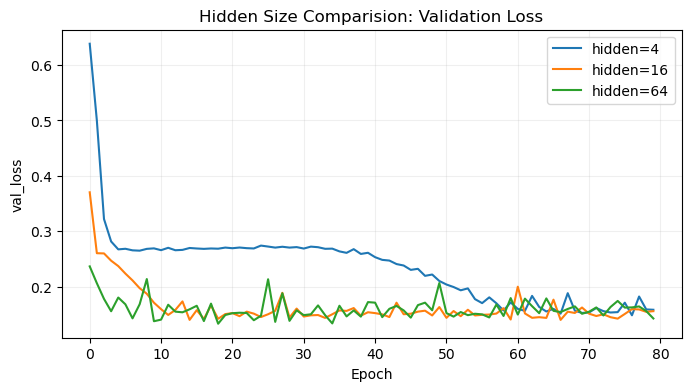

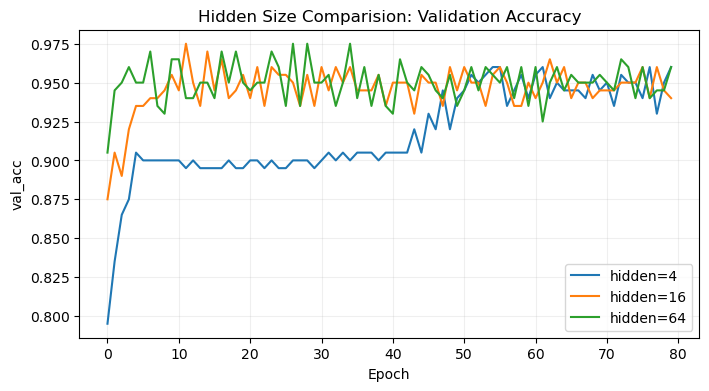

In [ ]:
hidden_size_results = {
    'hidden=4': train_model(hidden_size=4, epochs=80, seed=42),
    'hidden=16': train_model(hidden_size=16, epochs=80, seed=42),
    'hidden=64': train_model(hidden_size=64, epochs=80, seed=42),
}

summarize_final(hidden_size_results)
plot_metric(hidden_size_results, metric='val_loss', title='Hidden Size Comparision: Validation Loss')
plot_metric(hidden_size_results, metric='val_acc', title='Hidden Size Comparision: Validation Accuracy')

## 4. dropout rate 조절

dropout은 학습 중 일부 뉴런을 무작위로 꺼서
특정 뉴런 몇 개에만 과하게 의존하지 않도록 돕는 regularization 기법이다.

- 너무 낮으면 regularization 효과가 약할 수 있다.
- 너무 높으면 필요한 정보까지 너무 많이 끊어 학습이 어려워질 수 있다.

즉 dropout rate도 적절한 구간을 실험으로 찾아야 한다.

    dropout=0.0 | final train acc: 0.9467 | final val acc: 0.9400 | best val acc: 0.9750
    dropout=0.3 | final train acc: 0.9467 | final val acc: 0.9550 | best val acc: 0.9750
    dropout=0.6 | final train acc: 0.9033 | final val acc: 0.9500 | best val acc: 0.9500


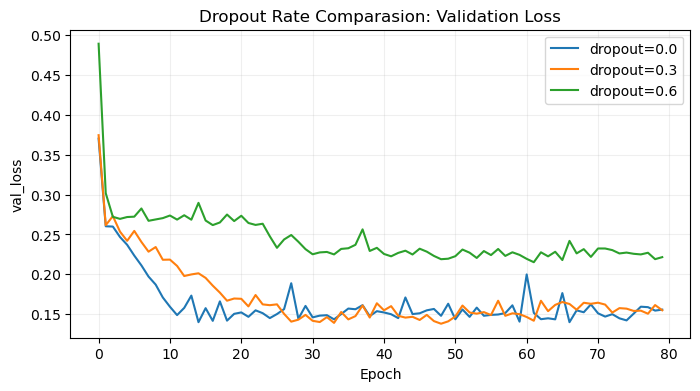

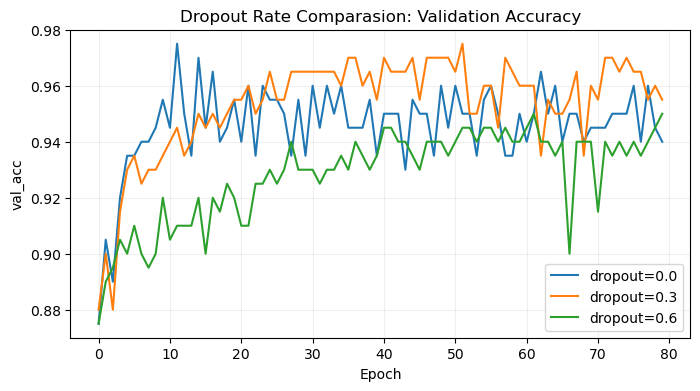

In [ ]:
dropout_results = {
    'dropout=0.0' : train_model(dropout_rate=0.0, epochs=80, seed=42),
    'dropout=0.3' : train_model(dropout_rate=0.3, epochs=80, seed=42),
    'dropout=0.6' : train_model(dropout_rate=0.6, epochs=80, seed=42),
}

summarize_final(dropout_results)
plot_metric(dropout_results, metric='val_loss', title='Dropout Rate Comparasion: Validation Loss')
plot_metric(dropout_results, metric='val_acc', title='Dropout Rate Comparasion: Validation Accuracy')

## 5. epoch 수 조절

epoch는 전체 학습 데이터를 몇 번 반복해서 볼지를 뜻한다.

- 너무 적으면 아직 덜 학습된 상태에서 끝날 수 있다.
- 너무 많으면 train 데이터에 점점 더 맞춰지며 과적합이 나타날 수 있다.

즉 epoch는 **학습 부족**과 **과적합** 사이를 살펴보는 기준이 된다.

      20 epochs | final train acc: 0.9483 | final val acc: 0.9550 | best val acc: 0.9750
      80 epochs | final train acc: 0.9467 | final val acc: 0.9400 | best val acc: 0.9750
     200 epochs | final train acc: 0.9517 | final val acc: 0.9450 | best val acc: 0.9750


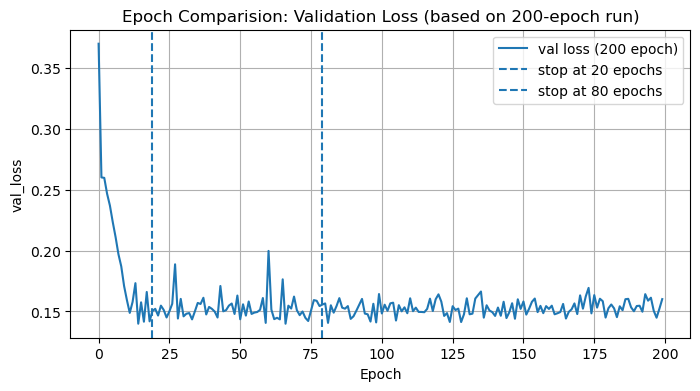

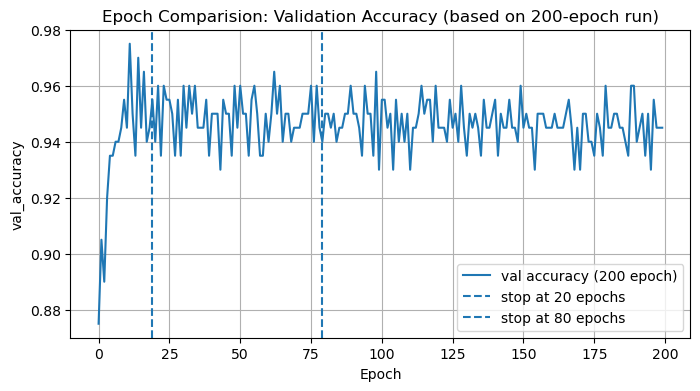

In [ ]:
epoch_results = {
    '20 epochs' : train_model(epochs=20, seed=42),
    '80 epochs' : train_model(epochs=80, seed=42),
    '200 epochs' : train_model(epochs=200, seed=42),
}

summarize_final(epoch_results)

# 가장 긴 실험(epochs=200)의 학습 곡선을 기준으로 시각화
# 20, 80 지점에 세로선 표시
long_history = epoch_results['200 epochs']

plt.figure(figsize=(8, 4))
plt.plot(long_history['val_loss'], label='val loss (200 epoch)')
plt.axvline(x=19, linestyle='--', label='stop at 20 epochs')
plt.axvline(x=79, linestyle='--', label='stop at 80 epochs')
plt.xlabel('Epoch')
plt.ylabel('val_loss')
plt.title('Epoch Comparision: Validation Loss (based on 200-epoch run)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(long_history['val_acc'], label='val accuracy (200 epoch)')
plt.axvline(x=19, linestyle='--', label='stop at 20 epochs')
plt.axvline(x=79, linestyle='--', label='stop at 80 epochs')
plt.xlabel('Epoch')
plt.ylabel('val_accuracy')
plt.title('Epoch Comparision: Validation Accuracy (based on 200-epoch run)')
plt.legend()
plt.grid()
plt.show()

## 하이퍼파라미터를 조절할 때의 기본 순서

처음부터 모든 하이퍼파라미터를 한꺼번에 바꾸면 무엇 때문에 성능이 달라졌는지 해석하기 어렵다.

초반에는 보통 다음 순서로 접근하면 좋다.

1. 기준 모델을 하나 정한다.
2. validation 기준 지표를 정한다.
3. learning rate를 먼저 조절한다.
4. batch size, hidden size를 조절한다.
5. 필요하면 dropout 같은 regularization 강도를 조절한다.
6. 결과를 기록하면서 비교한다.

## 자동 탐색 맛보기 - Optuna

지금까지는 learning rate, batch size, hidden size, dropout rate, epoch 수를 직접 바꿔보며
학습 곡선이 어떻게 달라지는지 확인했다.

이 과정은 매우 중요하다.
왜냐하면 딥러닝에서는 단순히 **정답 하이퍼파라미터** 를 찾는 것보다,
각 값이 loss와 accuracy에 어떤 영향을 주는지 해석할 수 있어야 하기 때문이다.

하지만 모든 조합을 사람이 직접 하나씩 바꿔보는 대신, 자동 탐색 도구를 활용해 더 효율적으로 하이퍼파라미터를 찾기도 한다.

여기서는 그 예시로 Optuna를 간단히 사용해본다.

Optuna는
- 여러 하이퍼파라미터 후보를 자동으로 시도하고
- 각 실험 결과를 비교하며
- 더 좋은 조합을 점점 찾아가는 방식의 도구이다.

이번 예제에서는 다음 하이퍼파라미터를 자동으로 탐색해본다.

- learning rate
- batch size
- hidden size
- dropout rate

In [ ]:
# Optuna가 설치되어 있지 않다면 먼저 설치한다.
# 주피터 노트북 환경에서는 아래 코드를 한 번 실행하면 된다.
# %conda install optuna

^C

Note: you may need to restart the kernel to use updated packages.


### 1.objective 함수 만들기

Optuna에서는 **한 번의 실험** 을 함수로 정의한다.
이 함수 안에서

1. 하이퍼파라미터 값을 하나 정하고
2. 그 값으로 모델을 학습한 뒤
3. validation 성능을 반환한다.

Optuna는 이 반환값을 기준으로 더 좋은 하이퍼파라미터 조합을 찾아간다.

여기서는 validation accuracy의 최고값을 기준으로 탐색해본다.

In [4]:
import optuna

# Optuna가 한 번의 trial에서 수행할 실험 함수
def objective(trial):
    # 탐색할 하이퍼파라미터 범위 정의

    # suggest_float: 연속적인 실수 범위 안에서 값을 고른다.
    lr = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # suggest_categorical: 미리 정한 후보 목록 중 하나를 고른다.
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    hidden_size = trial.suggest_categorical('hidden_size', [4, 16, 64])

    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.6)

    # 현재 trial에서 선택 된 하이퍼파라미터로 학습 수행
    history = train_model(
        lr=lr,
        batch_size=batch_size,
        hidden_size=hidden_size,
        dropout_rate=dropout_rate,
        epochs=50,
        seed=42
    )

    # validation accuracy 중 가장 높은 값을 반환
    # Optuna는 이 값을 최대화 하는 방향으로 탐색한다.
    best_val_acc = max(history['val_acc'])
    return best_val_acc

### 2. study 생성 및 탐색 실행

Optuna에게
**validation accuracy를 최대화하는 방향으로 trial을 여러 번 수행해줘**
라고 요청할 수 있다.

trial 수가 많을수록 더 많은 조합을 시도해볼 수 있지만,
딥러닝은 한 번 학습 비용이 있기 때문에
처음에는 너무 크게 시작하지 않는 것이 좋다.

여기서는 예시로 20번만 시도해본다.

In [5]:
# validation accuracy를 최대화하는 방향으로 탐색
study = optuna.create_study(direction='maximize')

# n_trials는 몇 번의 조합을 시도할지 결정하는 값
study.optimize(objective, n_trials=20)

[I 2026-04-13 12:16:24,843] A new study created in memory with name: no-name-67c47407-ea6d-42b1-83b0-dfbc884e9de0
[I 2026-04-13 12:16:28,911] Trial 0 finished with value: 0.9750000238418579 and parameters: {'lr': 0.003616428290622446, 'batch_size': 32, 'hidden_size': 64, 'dropout_rate': 0.23398910596934683}. Best is trial 0 with value: 0.9750000238418579.
[I 2026-04-13 12:16:30,117] Trial 1 finished with value: 0.9100000262260437 and parameters: {'lr': 0.005172551193317, 'batch_size': 64, 'hidden_size': 4, 'dropout_rate': 0.26074684982105256}. Best is trial 0 with value: 0.9750000238418579.
[I 2026-04-13 12:16:31,942] Trial 2 finished with value: 0.9700000286102295 and parameters: {'lr': 0.018794899400506035, 'batch_size': 32, 'hidden_size': 16, 'dropout_rate': 0.3542054421443968}. Best is trial 0 with value: 0.9750000238418579.
[I 2026-04-13 12:16:33,191] Trial 3 finished with value: 0.9750000238418579 and parameters: {'lr': 0.004948100738358349, 'batch_size': 64, 'hidden_size': 64, '

### 3. 가장 좋은 결과 확인

탐색이 끝나면
어떤 하이퍼파라미터 조합이 가장 좋았는지 확인할 수 있다.

In [6]:
print('Best trial value (best val acc):', study.best_value)
print('Best hyperparameters:')
for key, value in study.best_params.items():
    print(f'- {key} : {value}')

Best trial value (best val acc): 0.9800000190734863
Best hyperparameters:
- lr : 0.05942427345963411
- batch_size : 64
- hidden_size : 64
- dropout_rate : 0.5046224101388386


### 4. 가장 좋은 하이퍼파라미터로 다시 학습하기

Optuna가 찾아준 값은
**이번 탐색 범위와 조건 안에서 가장 좋았던 후보** 이다.

이제 그 값을 사용해 다시 한 번 모델을 학습시키고,
곡선을 확인해볼 수 있다.

In [8]:
best_params = study.best_params

best_history = train_model(
    lr=best_params['lr'],
    batch_size=best_params['batch_size'],
    hidden_size=best_params['hidden_size'],
    dropout_rate=best_params['dropout_rate'],
    epochs=80,
    seed=42
)

print('Best trial final train acc : ', best_history['train_acc'][-1])
print('Best trial final val acc : ', best_history['val_acc'][-1])
print('Best trial best val acc : ', max(best_history['val_acc']))

Best trial final train acc :  0.9233333468437195
Best trial final val acc :  0.9599999785423279
Best trial best val acc :  0.9800000190734863


### 5. 최적 하이퍼파라미터 결과 시각화

자동 탐색으로 찾은 설정도
결국 사람이 loss와 accuracy 곡선을 읽고 해석해야 한다.

즉 자동 탐색은
**좋은 후보를 빨리 찾는 도구** 이지,
곡선을 읽는 과정을 완전히 대신해주는 것은 아니다.

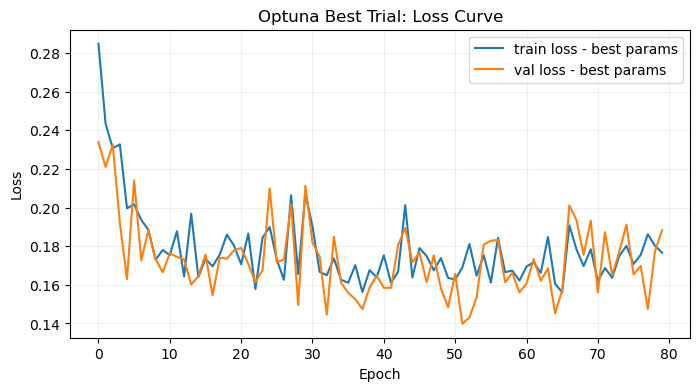

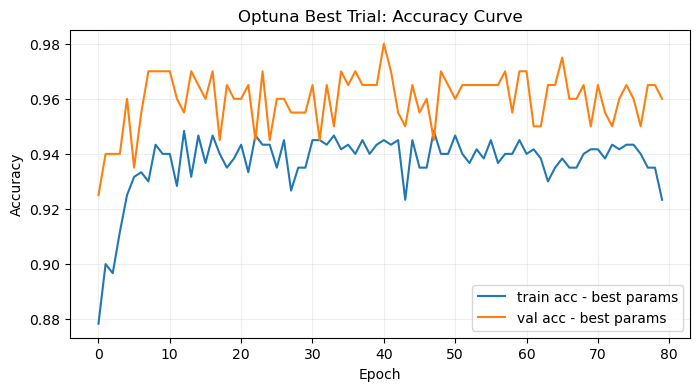

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(best_history['train_loss'], label='train loss - best params')
plt.plot(best_history['val_loss'], label='val loss - best params')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optuna Best Trial: Loss Curve')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_history['train_acc'], label='train acc - best params')
plt.plot(best_history['val_acc'], label='val acc - best params')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Optuna Best Trial: Accuracy Curve')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 정리

1. 하이퍼파라미터는 모델이 자동으로 학습하는 값이 아니라, 사람이 정하는 설정값이다.
2. learning rate는 업데이트 크기와 관련이 있어 가장 먼저 조절해볼 만한 값이다.
3. batch size는 업데이트 빈도, 학습 안정성, 메모리 사용량과 연결된다.
4. hidden size는 모델 표현력과 과적합 위험에 영향을 준다.
5. dropout rate는 regularization 강도를 조절한다.
6. epoch 수는 학습 부족과 과적합 사이를 살펴보는 기준이 된다.
7. 초반에는 한 번에 하나씩 바꾸며 validation 기준으로 비교하는 습관이 중요하다.
8. 이 과정을 Optuna 같은 자동 탐색 도구로 일부 자동화할 수 있다.